In [1]:
!pip install -q datasets transformers accelerate

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from datasets import load_dataset

dataset = load_dataset('/content/drive/MyDrive/endocellgraph')

In [5]:
splits = dataset["train"].train_test_split(
    test_size=0.1,
    seed=42,
    stratify_by_column="label"
)

In [6]:
train_ds = splits['train']
val_ds = splits['test']

In [7]:
id2label = {
    id: label
    for id, label in enumerate(train_ds.features['label'].names)
}

In [8]:
label2id = {
    label: id
    for id, label in id2label.items()
}

In [9]:
print(id2label)

{0: 'Endometrial Hyperplasia', 1: 'Endometrial Polyp', 2: 'Endometriod Adenocarcinoma', 3: 'Normal Endometrium'}


In [ ]:
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov2-base"
)

In [11]:
from torchvision.transforms import (
    CenterCrop,
    Compose,
    Normalize,
    RandomHorizontalFlip,
    RandomResizedCrop,
    Resize,
    ToTensor,
    ColorJitter,
)

In [12]:
image_mean = processor.image_mean
image_std = processor.image_std
size = 224

In [13]:
print(processor.size)

SizeDict(height=None, width=None, longest_edge=None, shortest_edge=256, max_height=None, max_width=None)


In [14]:
normalize = Normalize(
    mean=image_mean,
    std=image_std
)

In [15]:
_train_transforms = Compose([
    RandomResizedCrop(size),
    RandomHorizontalFlip(),

    ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    ToTensor(),
    normalize,
])

In [16]:
_val_transforms = Compose([
    Resize(size),
    CenterCrop(size),
    ToTensor(),
    normalize,
])

In [17]:
def train_transforms(examples):
    examples["pixel_values"] = [
        _train_transforms(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

In [18]:
def val_transforms(examples):
    examples["pixel_values"] = [
        _val_transforms(image.convert("RGB"))
        for image in examples["image"]
    ]
    return examples

In [19]:
train_ds.set_transform(train_transforms)
val_ds.set_transform(val_transforms)

In [20]:
from torch.utils.data import DataLoader
import torch

In [21]:
def collate_fn(examples):
    pixel_values = torch.stack(
        [example["pixel_values"] for example in examples]
    )

    labels = torch.tensor(
        [example["label"] for example in examples]
    )

    return {
        "pixel_values": pixel_values,
        "labels": labels,
    }

In [22]:
train_dataloader = DataLoader(
    train_ds,
    collate_fn=collate_fn,
    batch_size=4
)

In [23]:
batch = next(iter(train_dataloader))

for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        print(k, v.shape)

pixel_values torch.Size([4, 3, 224, 224])
labels torch.Size([4])


In [ ]:
from transformers import AutoModelForImageClassification

model = AutoModelForImageClassification.from_pretrained(
    "facebook/dinov2-base",
    num_labels=len(id2label),
    ignore_mismatched_sizes=True,
    id2label=id2label,
    label2id=label2id,
)

In [26]:
from transformers import TrainingArguments, Trainer

metric_name = "accuracy"

args = TrainingArguments(
    output_dir="dinov2-et",
    save_strategy="epoch",
    eval_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=30,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model=metric_name,

    logging_dir="logs",

    remove_unused_columns=False,

    fp16=True,

    report_to="none",
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
)

In [28]:
import numpy as np

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    probs = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro"
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    auc = roc_auc_score(
        labels,
        probs,
        multi_class="ovr",
        average="macro"
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
    }

In [29]:
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collate_fn,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

In [32]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Auc
0.075178,1.118203,30,0.882530,0.884037,0.874247,0.878922,0.970653


{'eval_loss': 1.1182031631469727,
 'eval_accuracy': 0.8825301204819277,
 'eval_precision': 0.8840373005201152,
 'eval_recall': 0.874247258749057,
 'eval_f1': 0.8789218028348463,
 'eval_auc': 0.9706527828497133}

In [34]:
predictions = trainer.predict(val_ds)

y_true = predictions.label_ids

y_pred = np.argmax(
    predictions.predictions,
    axis=1
)

probs = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

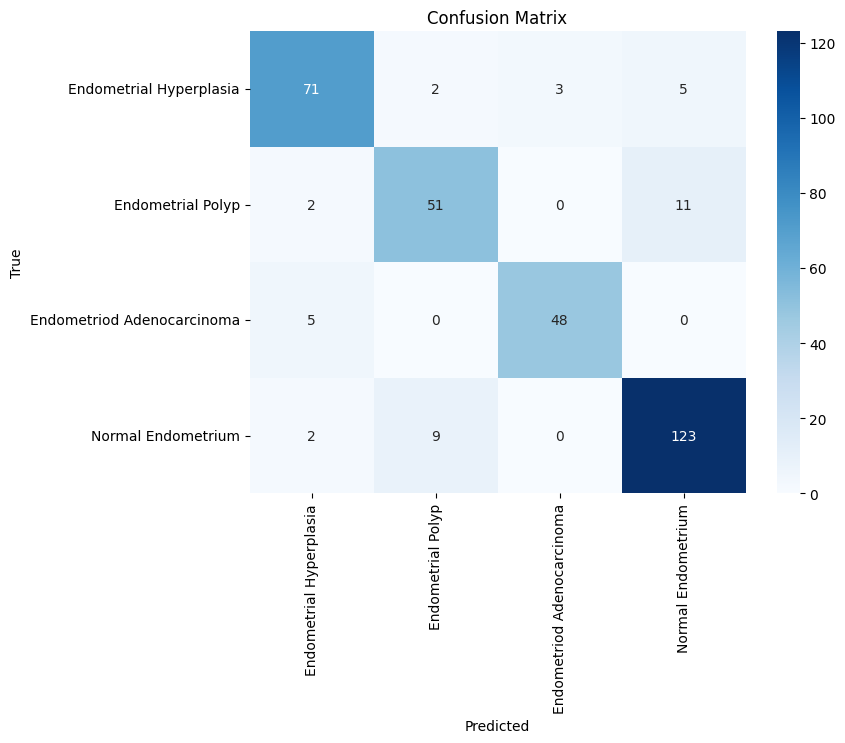

In [35]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(label2id.keys()),
    yticklabels=list(label2id.keys())
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [36]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=list(label2id.keys())
    )
)

                            precision    recall  f1-score   support

   Endometrial Hyperplasia       0.89      0.88      0.88        81
         Endometrial Polyp       0.82      0.80      0.81        64
Endometriod Adenocarcinoma       0.94      0.91      0.92        53
        Normal Endometrium       0.88      0.92      0.90       134

                  accuracy                           0.88       332
                 macro avg       0.88      0.87      0.88       332
              weighted avg       0.88      0.88      0.88       332



In [37]:
from sklearn.metrics import recall_score

sensitivity = recall_score(
    y_true,
    y_pred,
    average="macro"
)

specificities = []

for i in range(len(cm)):

    TP = cm[i,i]
    FN = cm[i,:].sum() - TP
    FP = cm[:,i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    specificities.append(
        TN/(TN+FP)
    )

specificity = np.mean(
    specificities
)

print(f"Sensitivity : {sensitivity:.4f}")
print(f"Specificity : {specificity:.4f}")

Sensitivity : 0.8742
Specificity : 0.9579


In [38]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_true,
    probs,
    multi_class="ovr",
    average="macro"
)

print(f"ROC-AUC : {auc:.4f}")

ROC-AUC : 0.9707
